# Semi-synthetic results — paper mock-up

This notebook is ready for the planned multi-dataset CoxPH-margin experiment with Gaussian, Clayton, and Frank copulas. It prefers `results/semi-synthetic/results_raw.csv`, then the current SUPPORT pilot directory, and otherwise generates deterministic mock rows.

The mock values are illustrative and must never be reported. Set `REFERENCE_MODEL` before looking at test results; it must be chosen by the validation protocol rather than selected post hoc.

In [7]:
from pathlib import Path
import os
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
USE_TEX = os.environ.get("DVFM_USE_TEX", "auto").lower() in {"1", "true", "yes"} or (os.environ.get("DVFM_USE_TEX", "auto").lower() == "auto" and shutil.which("latex") is not None)
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 14.0,
    "legend.fontsize": "large",
    "text.usetex": USE_TEX,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
RESULT_CANDIDATES = [ROOT / "results" / "semi-synthetic", ROOT / "results" / "semi-synthetic-support"]
FIGURE_DIR = ROOT / "paper" / "figures"
TABLE_DIR = ROOT / "paper" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_MODEL = "CoxPH"  # Freeze using validation data before opening test results.
FOREST_COPULA = "Clayton"
TARGET_TAU = 0.50
print(f"LaTeX rendering: {USE_TEX}")

LaTeX rendering: True


In [8]:
def snake_case(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

def canonicalize(frame):
    out = frame.rename(columns={column: snake_case(column) for column in frame.columns}).copy()
    aliases = {
        "dataset_name": "dataset", "target_censoring": "target_censoring_rate",
        "censoring_rate": "target_censoring_rate", "kendall_tau": "target_kendall_tau",
        "oracle_joint_ise": "oracle_joint_survival_ise",
    }
    out = out.rename(columns={key: value for key, value in aliases.items() if key in out and value not in out})
    if "model" in out:
        names = {"dvfm": "DVFM", "coxph": "CoxPH", "deepsurv": "DeepSurv", "rsf": "RSF", "gbsa": "GBSA", "mtlr": "MTLR", "deephit": "DeepHit", "hacsurv": "HACSurv", "clayton_aft": "ClaytonAFT"}
        out["model"] = out["model"].astype(str).str.lower().map(names).fillna(out["model"].astype(str))
        if "latent_dim" in out:
            z0 = out["model"].eq("DVFM") & pd.to_numeric(out["latent_dim"], errors="coerce").eq(0)
            out.loc[z0, "model"] = "DVFM-z0"
    if "copula" in out:
        out["copula"] = out["copula"].astype(str).str.title()
    return out

def make_mock_semisynthetic(seed=2026):
    rng = np.random.default_rng(seed)
    datasets = ["SUPPORT", "METABRIC", "GBSG", "FLCHAIN", "PBC", "WHAS500", "NWTCO", "AIDS", "Veteran", "Rossi"]
    copulas = ["Gaussian", "Clayton", "Frank"]
    models = ["DVFM", "DVFM-z0", "CoxPH", "DeepSurv", "RSF", "GBSA", "MTLR", "DeepHit", "ClaytonAFT", "HACSurv"]
    model_shift = {"DVFM": -0.020, "DVFM-z0": 0.000, "CoxPH": 0.006, "DeepSurv": 0.002, "RSF": 0.004, "GBSA": 0.003, "MTLR": 0.001, "DeepHit": 0.005, "ClaytonAFT": -0.006, "HACSurv": -0.010}
    rows = []
    for d, dataset in enumerate(datasets):
        dataset_effect = rng.normal(0, 0.012)
        for copula in copulas:
            mismatch = {"Gaussian": 0.000, "Clayton": -0.004, "Frank": 0.004}[copula]
            for censoring in (0.25, 0.50, 0.75):
                for repeat in range(10):
                    shared_noise = rng.normal(0, 0.003)
                    for model in models:
                        dependence_gain = (TARGET_TAU * censoring) if model in {"DVFM", "HACSurv", "ClaytonAFT"} else 0.0
                        ibs = 0.125 + dataset_effect + 0.055 * censoring + model_shift[model] - 0.018 * dependence_gain + shared_noise + rng.normal(0, 0.003)
                        learned = np.nan
                        joint_ise = np.nan
                        frailty = np.nan
                        if model == "DVFM":
                            learned = np.clip(TARGET_TAU + mismatch - 0.035 * censoring + rng.normal(0, 0.025), 0, 1)
                            joint_ise = 0.010 + 0.025 * censoring + abs(mismatch) + rng.normal(0, 0.002)
                            frailty = np.clip(0.78 - 0.24 * censoring + {"Gaussian": 0.04, "Clayton": 0.00, "Frank": -0.10}[copula] + rng.normal(0, 0.035), -1, 1)
                        elif model == "HACSurv":
                            learned = np.clip(TARGET_TAU + 0.045 + mismatch + rng.normal(0, 0.04), 0, 1)
                            joint_ise = 0.016 + 0.032 * censoring + abs(mismatch) + rng.normal(0, 0.003)
                        rows.append({
                            "dataset": dataset, "copula": copula, "target_kendall_tau": TARGET_TAU,
                            "target_censoring_rate": censoring, "repeat": repeat, "model": model,
                            "oracle_ibs": ibs,
                            "oracle_ci": 0.75 - 0.55 * (ibs - 0.12) + rng.normal(0, 0.007),
                            "oracle_mae": 0.75 + 3.2 * ibs + rng.normal(0, 0.035),
                            "frailty_spearman": frailty,
                            "learned_conditional_kendall_tau": learned,
                            "absolute_conditional_kendall_tau_error": abs(learned - TARGET_TAU) if np.isfinite(learned) else np.nan,
                            "oracle_joint_survival_ise": joint_ise, "numerical_failure": False,
                        })
    characteristics = pd.DataFrame({
        "Dataset": datasets,
        "$N$": [9105, 1904, 2232, 7874, 418, 500, 4028, 1151, 137, 432],
        "Features": [14, 9, 7, 9, 17, 14, 8, 11, 8, 7],
        "Original event rate": [0.68, 0.58, 0.43, 0.28, 0.39, 0.43, 0.14, 0.08, 0.93, 0.26],
        "Split": ["70/10/20"] * 10,
    })
    return pd.DataFrame(rows), characteristics

result_path = next((path / "results_raw.csv" for path in RESULT_CANDIDATES if (path / "results_raw.csv").exists()), None)
if result_path is not None:
    results = canonicalize(pd.read_csv(result_path))
    characteristics_path = result_path.parent / "dataset_characteristics.csv"
    characteristics = pd.read_csv(characteristics_path) if characteristics_path.exists() else None
    DATA_SOURCE = "REAL RESULTS"
else:
    results, characteristics = make_mock_semisynthetic()
    DATA_SOURCE = "MOCK DATA — DO NOT REPORT"
required = {"dataset", "copula", "target_censoring_rate", "repeat", "model", "oracle_ibs"}
missing = required - set(results.columns)
if missing:
    raise ValueError(f"Results are missing canonical columns: {sorted(missing)}")
print(DATA_SOURCE, f"| rows={len(results):,} | datasets={results['dataset'].nunique()}")

MOCK DATA — DO NOT REPORT | rows=9,000 | datasets=10


## Figure 1: paired predictive improvement by dataset

Negative values favor DVFM. The reference model must be fixed using validation results before test evaluation. The main-paper copula can be changed with `FOREST_COPULA`.

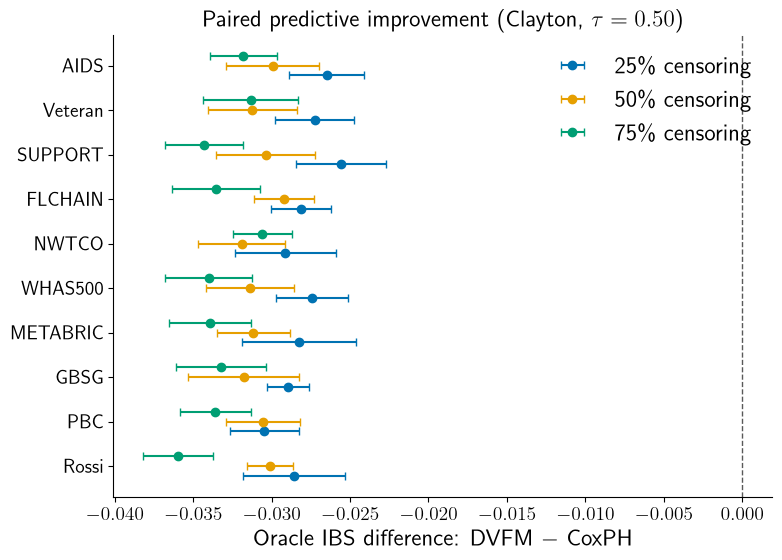

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_dataset_forest.pdf


In [9]:
forest = results[results["copula"].eq(FOREST_COPULA) & results["model"].isin(["DVFM", REFERENCE_MODEL])].copy()
paired = forest.pivot_table(index=["dataset", "target_censoring_rate", "repeat"], columns="model", values="oracle_ibs").dropna().reset_index()
paired["delta_ibs"] = paired["DVFM"] - paired[REFERENCE_MODEL]
summary = paired.groupby(["dataset", "target_censoring_rate"])["delta_ibs"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
order = summary.groupby("dataset")["mean"].mean().sort_values().index.tolist()
y = np.arange(len(order))
offsets = {0.25: -0.22, 0.50: 0.0, 0.75: 0.22}
colors = {0.25: "#0072B2", 0.50: "#E69F00", 0.75: "#009E73"}
fig, ax = plt.subplots(figsize=(8.5, 6.0))
for censoring in offsets:
    part = summary[summary["target_censoring_rate"].eq(censoring)].set_index("dataset").reindex(order)
    ax.errorbar(part["mean"], y + offsets[censoring], xerr=part["ci95"], fmt="o", capsize=3, color=colors[censoring], label=rf"{100*censoring:.0f}\% censoring")
ax.axvline(0, color="0.35", linewidth=1, linestyle="--")
ax.set(yticks=y, yticklabels=order, xlabel=rf"Oracle IBS difference: DVFM $-$ {REFERENCE_MODEL}", title=rf"Paired predictive improvement ({FOREST_COPULA}, $\tau={TARGET_TAU:.2f}$)")
ax.legend(frameon=False)
out = FIGURE_DIR / "semi_synthetic_dataset_forest.pdf"
fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")

## Figure 2: recovery and mechanistic prediction benefit

Points are dataset-balanced means; intervals use datasets—not pooled subjects—as the unit of uncertainty. Frank frailty is shown separately because its discrete mixing variable is not scale-comparable with Gaussian or Clayton frailty.

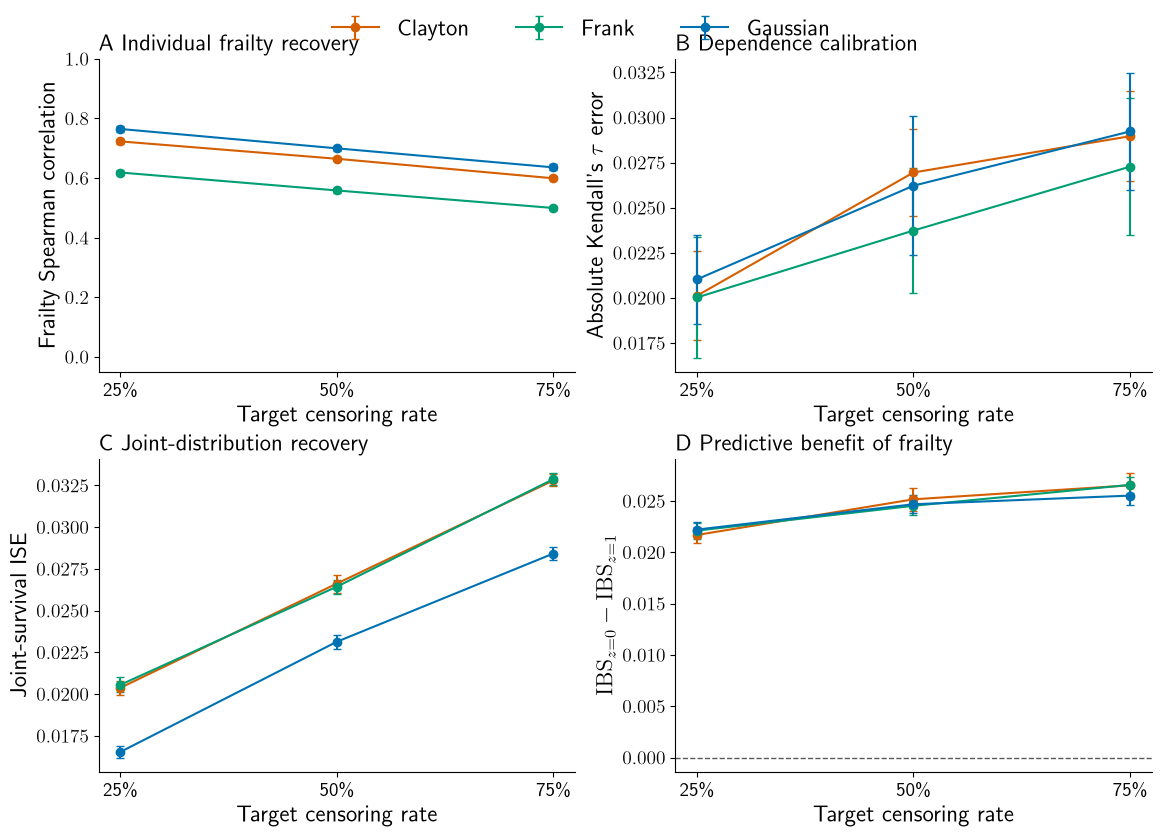

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_recovery.pdf


In [10]:
def dataset_balanced_summary(frame, metric):
    per_dataset = frame.groupby(["dataset", "copula", "target_censoring_rate"], as_index=False)[metric].mean()
    out = per_dataset.groupby(["copula", "target_censoring_rate"])[metric].agg(["mean", "std", "count"]).reset_index()
    out["ci95"] = 1.96 * out["std"] / np.sqrt(out["count"])
    return out

dvfm = results[results["model"].eq("DVFM")].copy()
mechanistic = results[results["model"].isin(["DVFM", "DVFM-z0"])].pivot_table(
    index=["dataset", "copula", "target_censoring_rate", "repeat"], columns="model", values="oracle_ibs"
).dropna().reset_index()
mechanistic["oracle_ibs_gain"] = mechanistic["DVFM-z0"] - mechanistic["DVFM"]
summaries = [
    (dataset_balanced_summary(dvfm, "frailty_spearman"), "Frailty Spearman correlation", "A  Individual frailty recovery"),
    (dataset_balanced_summary(dvfm, "absolute_conditional_kendall_tau_error"), r"Absolute Kendall's $\tau$ error", "B  Dependence calibration"),
    (dataset_balanced_summary(dvfm, "oracle_joint_survival_ise"), "Joint-survival ISE", "C  Joint-distribution recovery"),
    (dataset_balanced_summary(mechanistic, "oracle_ibs_gain"), r"$\mathrm{IBS}_{z=0}-\mathrm{IBS}_{z=1}$", "D  Predictive benefit of frailty"),
]
palette = {"Gaussian": "#0072B2", "Clayton": "#D55E00", "Frank": "#009E73"}
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), constrained_layout=True)
for ax, (summary, ylabel, title) in zip(axes.flat, summaries):
    for copula, part in summary.groupby("copula"):
        ax.errorbar(part["target_censoring_rate"], part["mean"], yerr=part["ci95"], marker="o", capsize=3, label=copula, color=palette.get(copula))
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Target censoring rate")
    ax.set_ylabel(ylabel)
    ax.set_xticks([0.25, 0.50, 0.75], [r"25\%", r"50\%", r"75\%"])
axes[0, 0].set_ylim(-0.05, 1.0)
axes[1, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.04))
out = FIGURE_DIR / "semi_synthetic_recovery.pdf"
fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")

## Tables

The notebook writes booktabs-compatible LaTeX directly. Table 1 describes the datasets. Table 2 reports scenario-balanced ranks and paired wins/ties/losses; full dataset-by-model values belong in the supplement.

In [11]:
if characteristics is None:
    print("dataset_characteristics.csv is absent; write this file during generation to enable Table 1.")
else:
    dataset_table = characteristics.copy()
    for column in dataset_table.select_dtypes(include="number"):
        if "rate" in column.lower():
            dataset_table[column] = dataset_table[column].map(lambda value: f"{value:.2f}")
    latex = dataset_table.to_latex(
        index=False, escape=False,
        caption="Characteristics of the source datasets used for semi-synthetic evaluation.",
        label="tab:semi_synthetic_datasets",
        column_format="lrrrr",
    )
    out = TABLE_DIR / "semi_synthetic_datasets.tex"
    out.write_text(latex, encoding="utf-8")
    print(latex)
    print(f"{DATA_SOURCE} | wrote {out}")

\begin{table}
\caption{Characteristics of the source datasets used for semi-synthetic evaluation.}
\label{tab:semi_synthetic_datasets}
\begin{tabular}{lrrrr}
\toprule
Dataset & $N$ & Features & Original event rate & Split \\
\midrule
SUPPORT & 9105 & 14 & 0.68 & 70/10/20 \\
METABRIC & 1904 & 9 & 0.58 & 70/10/20 \\
GBSG & 2232 & 7 & 0.43 & 70/10/20 \\
FLCHAIN & 7874 & 9 & 0.28 & 70/10/20 \\
PBC & 418 & 17 & 0.39 & 70/10/20 \\
WHAS500 & 500 & 14 & 0.43 & 70/10/20 \\
NWTCO & 4028 & 8 & 0.14 & 70/10/20 \\
AIDS & 1151 & 11 & 0.08 & 70/10/20 \\
Veteran & 137 & 8 & 0.93 & 70/10/20 \\
Rossi & 432 & 7 & 0.26 & 70/10/20 \\
\bottomrule
\end{tabular}
\end{table}

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_datasets.tex


In [12]:
comparison = results[~results["model"].eq("DVFM-z0")].copy()
scenario_keys = ["dataset", "copula", "target_censoring_rate"]
scenario_model = comparison.groupby(scenario_keys + ["model"], as_index=False).agg(
    oracle_ibs=("oracle_ibs", "mean"), oracle_ci=("oracle_ci", "mean"), oracle_mae=("oracle_mae", "mean"),
    failures=("numerical_failure", "sum"),
)
scenario_model["ibs_rank"] = scenario_model.groupby(scenario_keys)["oracle_ibs"].rank(method="average")
scenario_model["ci_rank"] = scenario_model.groupby(scenario_keys)["oracle_ci"].rank(method="average", ascending=False)
scenario_model["mae_rank"] = scenario_model.groupby(scenario_keys)["oracle_mae"].rank(method="average")
rank_table = scenario_model.groupby("model", as_index=False).agg(
    IBS=("ibs_rank", "mean"), CI=("ci_rank", "mean"), MAE=("mae_rank", "mean"), Failures=("failures", "sum"),
)
dvfm_ibs = scenario_model[scenario_model["model"].eq("DVFM")][scenario_keys + ["oracle_ibs"]].rename(columns={"oracle_ibs": "dvfm_ibs"})
paired_models = scenario_model.merge(dvfm_ibs, on=scenario_keys, how="left")
tol = 1e-4
paired_models["outcome"] = np.where(paired_models["oracle_ibs"] < paired_models["dvfm_ibs"] - tol, "W", np.where(paired_models["oracle_ibs"] > paired_models["dvfm_ibs"] + tol, "L", "T"))
wtl = paired_models.groupby(["model", "outcome"]).size().unstack(fill_value=0).reindex(columns=["W", "T", "L"], fill_value=0)
wtl["W/T/L vs DVFM"] = wtl.astype(int).astype(str).agg("/".join, axis=1)
rank_table = rank_table.merge(wtl[["W/T/L vs DVFM"]], left_on="model", right_index=True, how="left")
rank_table.loc[rank_table["model"].eq("DVFM"), "W/T/L vs DVFM"] = "--"
rank_table = rank_table.sort_values("IBS").rename(columns={"model": "Model", "IBS": "IBS rank", "CI": "CI rank", "MAE": "MAE rank"})
for column in ["IBS rank", "CI rank", "MAE rank"]:
    rank_table[column] = rank_table[column].map(lambda value: f"{value:.2f}")
rank_table["Failures"] = rank_table["Failures"].astype(int)
latex = rank_table.to_latex(
    index=False, escape=False,
    caption="Scenario-balanced semi-synthetic performance. Lower mean rank is better. Wins, ties, and losses use oracle IBS and are reported from each comparator's perspective.",
    label="tab:semi_synthetic_models",
    column_format="lrrrrr",
)
out = TABLE_DIR / "semi_synthetic_model_summary.tex"
out.write_text(latex, encoding="utf-8")
print(latex)
print(f"{DATA_SOURCE} | wrote {out}")

\begin{table}
\caption{Scenario-balanced semi-synthetic performance. Lower mean rank is better. Wins, ties, and losses use oracle IBS and are reported from each comparator's perspective.}
\label{tab:semi_synthetic_models}
\begin{tabular}{lrrrrr}
\toprule
Model & IBS rank & CI rank & MAE rank & Failures & W/T/L vs DVFM \\
\midrule
DVFM & 1.00 & 1.01 & 1.02 & 0 & -- \\
HACSurv & 2.00 & 2.26 & 2.21 & 0 & 0/0/90 \\
ClaytonAFT & 3.00 & 2.88 & 2.80 & 0 & 0/0/90 \\
MTLR & 4.32 & 5.51 & 5.71 & 0 & 0/0/90 \\
DeepSurv & 5.06 & 5.86 & 5.88 & 0 & 0/0/90 \\
GBSA & 5.94 & 6.26 & 6.46 & 0 & 0/0/90 \\
RSF & 7.17 & 6.60 & 6.46 & 0 & 0/0/90 \\
DeepHit & 7.87 & 7.23 & 7.11 & 0 & 0/0/90 \\
CoxPH & 8.64 & 7.40 & 7.36 & 0 & 0/0/90 \\
\bottomrule
\end{tabular}
\end{table}

MOCK DATA — DO NOT REPORT | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_model_summary.tex
